In [8]:
import pandas as pd

In [9]:
shopping_trends = pd.read_excel(r"C:\Users\HP\Documents\Personal\Semester 3\Programming Fundamentals\shopping_trends.xlsx")
shopping_trends

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


# What's the average age of consumers making purchases, and does it vary across different item categories?


In [3]:
shopping_trends.groupby('Age').mean()

C:\Users\HP\AppData\Local\Temp\ipykernel_7140\433979467.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  shopping_trends.groupby('Age').mean()


,Customer ID,Purchase Amount (USD),Review Rating,Previous Purchases
Age,,,,
18,1995.478261,59.985507,3.744928,21.028986
19,1955.765432,61.000000,3.820988,24.481481
20,1752.564516,55.225806,3.841935,23.258065
21,1830.159420,64.101449,3.815942,23.913043
22,2118.757576,60.772727,3.730303,26.636364
23,2089.028169,56.746479,3.914085,25.070423
24,1904.323529,63.102941,3.744118,25.132353
25,1784.811765,63.200000,3.894118,26.976471
26,2113.347826,61.043478,3.788406,23.869565


In [6]:
overall_average_age = shopping_trends['Age'].mean()
average_age_per_category = shopping_trends.groupby('Category')['Age'].mean()
print(f"Overall average Age is: {overall_average_age}")
print(f"Average age per Category is: {average_age_per_category}")

Overall average Age is: 44.06846153846154
Average age per Category is: Category
Accessories    44.224194
Clothing       43.782959
Footwear       44.442404
Outerwear      44.311728
Name: Age, dtype: float64


# Is there a significant difference in shopping behaviour between Genders?


In [9]:
average_purchase_by_gender = shopping_trends.groupby('Gender')['Purchase Amount (USD)'].mean()
print(average_purchase_by_gender)

Gender
Female    60.249199
Male      59.536199
Name: Purchase Amount (USD), dtype: float64


In [10]:
count_payment_by_gender = shopping_trends.groupby('Gender')['Payment Method'].count()
print(count_payment_by_gender)

Gender
Female    1248
Male      2652
Name: Payment Method, dtype: int64


In [15]:
import pandas as pd


data = {
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Male'],
    'Size': ['L', 'M', 'S', 'XL', 'L']
}
df = pd.DataFrame(data)


contingency_table = pd.crosstab(shopping_trends['Gender'], shopping_trends['Size'])

print(contingency_table)


Size      L     M    S   XL
Gender                     
Female  337   590  187  134
Male    716  1165  476  295


# Which item category generates the highest total purchase amount, and is there a correlation with the season?


In [17]:
sum_amount_by_gender = shopping_trends.groupby('Gender')['Purchase Amount (USD)'].sum()
print(sum_amount_by_gender)


Gender
Female     75191
Male      157890
Name: Purchase Amount (USD), dtype: int64


In [19]:
total_purchase_by_category = shopping_trends.groupby('Category')['Purchase Amount (USD)'].sum()
print(total_purchase_by_category)

Category
Accessories     74200
Clothing       104264
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64


# Do certain locations tend to spend more on shopping, and does this relate to specific item categories?

In [26]:
total_purchase_by_location = shopping_trends.groupby('Location')['Purchase Amount (USD)'].sum()
print(total_purchase_by_location)

Location
Alabama           5261
Alaska            4867
Arizona           4326
Arkansas          4828
California        5605
Colorado          4222
Connecticut       4226
Delaware          4758
Florida           3798
Georgia           4645
Hawaii            3752
Idaho             5587
Illinois          5617
Indiana           4655
Iowa              4201
Kansas            3437
Kentucky          4402
Louisiana         4848
Maine             4388
Maryland          4795
Massachusetts     4384
Michigan          4533
Minnesota         4977
Mississippi       4883
Missouri          4691
Montana           5784
Nebraska          5172
Nevada            5514
New Hampshire     4219
New Jersey        3802
New Mexico        5014
New York          5257
North Carolina    4742
North Dakota      5220
Ohio              4649
Oklahoma          4376
Oregon            4243
Pennsylvania      4926
Rhode Island      3871
South Carolina    4439
South Dakota      4236
Tennessee         4772
Texas             4712
Ut

In [28]:
total_purchase_by_location = shopping_trends.groupby(['Location','Category'])['Purchase Amount (USD)'].sum()
print(total_purchase_by_location)

Location   Category   
Alabama    Accessories    1576
           Clothing       2334
           Footwear        914
           Outerwear       437
Alaska     Accessories    1719
                          ... 
Wisconsin  Outerwear       120
Wyoming    Accessories    1388
           Clothing       1850
           Footwear        703
           Outerwear       368
Name: Purchase Amount (USD), Length: 200, dtype: int64


# Is there a preference for a particular size or color within certain item categories?

In [29]:
size_preference = shopping_trends.groupby('Category')['Size'].size()
print(size_preference)

Category
Accessories    1240
Clothing       1737
Footwear        599
Outerwear       324
Name: Size, dtype: int64


In [33]:
color_preference = shopping_trends.groupby('Category')['Color'].count()
print(color_preference)

Category
Accessories    1240
Clothing       1737
Footwear        599
Outerwear       324
Name: Color, dtype: int64


# How does the review rating correlate with the purchase amount and frequency of purchases?


In [42]:
average_purchase_by_rating = shopping_trends.groupby('Review Rating')['Purchase Amount (USD)'].mean()

frequency_by_rating = shopping_trends.groupby('Review Rating').size()

print(average_purchase_by_rating)
print(frequency_by_rating)


Review Rating
2.5    62.287879
2.6    59.566038
2.7    59.363636
2.8    57.066176
2.9    56.470588
3.0    60.728395
3.1    58.770701
3.2    61.315789
3.3    59.861842
3.4    59.005495
3.5    58.833333
3.6    57.322148
3.7    58.974359
3.8    60.873239
3.9    58.926380
4.0    59.237569
4.1    61.959459
4.2    60.853801
4.3    59.673469
4.4    60.525316
4.5    59.489209
4.6    57.683908
4.7    59.283784
4.8    61.881944
4.9    63.885542
5.0    64.352941
Name: Purchase Amount (USD), dtype: float64
Review Rating
2.5     66
2.6    159
2.7    154
2.8    136
2.9    170
3.0    162
3.1    157
3.2    152
3.3    152
3.4    182
3.5    156
3.6    149
3.7    156
3.8    142
3.9    163
4.0    181
4.1    148
4.2    171
4.3    147
4.4    158
4.5    139
4.6    174
4.7    148
4.8    144
4.9    166
5.0     68
dtype: int64


In [43]:
age_by_rating = shopping_trends.groupby('Age')['Review Rating'].mean()
print(age_by_rating)

Age
18    3.744928
19    3.820988
20    3.841935
21    3.815942
22    3.730303
23    3.914085
24    3.744118
25    3.894118
26    3.788406
27    3.759036
28    3.668354
29    3.775000
30    3.821127
31    3.848101
32    3.667073
33    3.711111
34    3.658824
35    3.650000
36    3.800000
37    3.719481
38    3.805714
39    3.911765
40    3.709722
41    3.682558
42    3.730000
43    3.775949
44    3.782353
45    3.626389
46    3.636842
47    3.764789
48    3.783824
49    3.705952
50    3.825301
51    3.859722
52    3.621918
53    3.558571
54    3.693976
55    3.663014
56    3.758108
57    3.733333
58    3.739506
59    3.649333
60    3.752308
61    3.687692
62    3.846988
63    3.708000
64    3.673973
65    3.911111
66    3.623944
67    3.598148
68    3.908000
69    3.847727
70    3.744776
Name: Review Rating, dtype: float64


# What's the distribution of subscription status among customers, and does it influence their spending habits?


In [45]:
subscription_status = shopping_trends.groupby('Subscription Status').count()
print(subscription_status)

                     Customer ID   Age  Gender  Item Purchased  Category  \
Subscription Status                                                        
No                          2847  2847    2847            2847      2847   
Yes                         1053  1053    1053            1053      1053   

                     Purchase Amount (USD)  Location  Size  Color  Season  \
Subscription Status                                                         
No                                    2847      2847  2847   2847    2847   
Yes                                   1053      1053  1053   1053    1053   

                     Review Rating  Payment Method  Shipping Type  \
Subscription Status                                                 
No                            2847            2847           2847   
Yes                           1053            1053           1053   

                     Discount Applied  Promo Code Used  Previous Purchases  \
Subscription Status            

In [46]:
average_spending_by_subscription = shopping_trends.groupby('Subscription Status')['Purchase Amount (USD)'].mean()
print(average_spending_by_subscription)


Subscription Status
No     59.865121
Yes    59.491928
Name: Purchase Amount (USD), dtype: float64


# Which payment method is most commonly used, and is there a relationship between payment method and purchase amount?


In [52]:
common_payment_method = shopping_trends.groupby('Payment Method').count()
print(common_payment_method)

                Customer ID  Age  Gender  Item Purchased  Category  \
Payment Method                                                       
Bank Transfer           632  632     632             632       632   
Cash                    648  648     648             648       648   
Credit Card             696  696     696             696       696   
Debit Card              633  633     633             633       633   
PayPal                  638  638     638             638       638   
Venmo                   653  653     653             653       653   

                Purchase Amount (USD)  Location  Size  Color  Season  \
Payment Method                                                         
Bank Transfer                     632       632   632    632     632   
Cash                              648       648   648    648     648   
Credit Card                       696       696   696    696     696   
Debit Card                        633       633   633    633     633   
PayPal 

In [54]:
average_purchase_by_payment_method = shopping_trends.groupby('Payment Method')['Purchase Amount (USD)'].mean()
print(average_purchase_by_payment_method)

Payment Method
Bank Transfer    58.738924
Cash             59.927469
Credit Card      61.159483
Debit Card       58.638231
PayPal           58.697492
Venmo            61.241960
Name: Purchase Amount (USD), dtype: float64


# Are there specific shipping types preferred by customers, and does this influence their frequency of purchases?


In [55]:
shipping_preference = shopping_trends.groupby('Shipping Type').count()
print(shipping_preference)

                Customer ID  Age  Gender  Item Purchased  Category  \
Shipping Type                                                        
2-Day Shipping          627  627     627             627       627   
Express                 646  646     646             646       646   
Free Shipping           675  675     675             675       675   
Next Day Air            648  648     648             648       648   
Standard                654  654     654             654       654   
Store Pickup            650  650     650             650       650   

                Purchase Amount (USD)  Location  Size  Color  Season  \
Shipping Type                                                          
2-Day Shipping                    627       627   627    627     627   
Express                           646       646   646    646     646   
Free Shipping                     675       675   675    675     675   
Next Day Air                      648       648   648    648     648   
Standar

# Is there a noticeable pattern in the usage of discounts or promo codes among customers who make frequent purchases compared to occasional buyers?


In [71]:
shopping_trends.dropna(axis=0)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


In [73]:
shopping_trends.drop_duplicates()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,PayPal,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Cash,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,Cash,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,PayPal,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Credit Card,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,PayPal,Express,No,No,24,Venmo,Weekly


In [74]:
shopping_trends.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               3900 non-null   int64  
 1   Age                       3900 non-null   int64  
 2   Gender                    3900 non-null   object 
 3   Item Purchased            3900 non-null   object 
 4   Category                  3900 non-null   object 
 5   Purchase Amount (USD)     3900 non-null   int64  
 6   Location                  3900 non-null   object 
 7   Size                      3900 non-null   object 
 8   Color                     3900 non-null   object 
 9   Season                    3900 non-null   object 
 10  Review Rating             3900 non-null   float64
 11  Subscription Status       3900 non-null   object 
 12  Payment Method            3900 non-null   object 
 13  Shipping Type             3900 non-null   object 
 14  Discount

In [76]:
shopping_trends.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [12]:
clothing_data = shopping_trends[shopping_trends['Category'] == 'Clothing']

grouped_data = clothing_data.groupby(['Discount Applied', 'Age', 'Gender']).size()


grouped_sales = grouped_data.reset_index(name='Sales Volume')


grouped_sales.head()


,Discount Applied,Age,Gender,Sales Volume
0,No,18,Female,8
1,No,18,Male,6
2,No,19,Female,10
3,No,19,Male,13
4,No,20,Female,6


In [13]:
clothing_data = shopping_trends[shopping_trends['Category'] == 'Clothing']

grouped_data = clothing_data.groupby(['Discount Applied', 'Age', 'Gender']).size()

grouped_data.head()

Discount Applied  Age  Gender
No                18   Female     8
                       Male       6
                  19   Female    10
                       Male      13
                  20   Female     6
dtype: int64

# Matplotlib


# What is the overall impact of discounts on the sale volume of 'Clothing' items, depicted through a comparative bar chart?

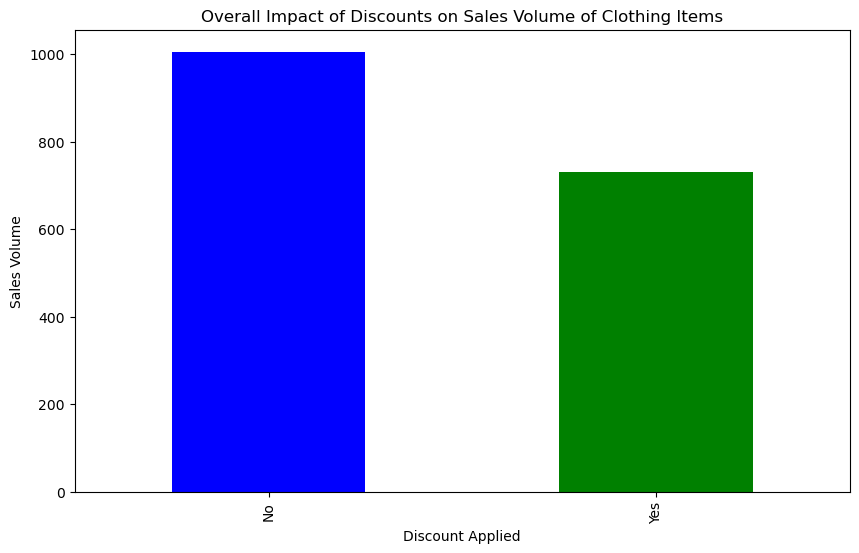

In [15]:
import matplotlib.pyplot as plt


clothing_data = shopping_trends[shopping_trends['Category'] == 'Clothing']

grouped_data = clothing_data.groupby(['Discount Applied']).size()


plt.figure(figsize=(10, 6))
grouped_data.plot(kind='bar', color=['blue', 'green'])


plt.title('Overall Impact of Discounts on Sales Volume of Clothing Items')
plt.xlabel('Discount Applied')
plt.ylabel('Sales Volume')
 


plt.show()

# How does the impact of discounts on 'Clothing' sales vary among different age groups and genders?


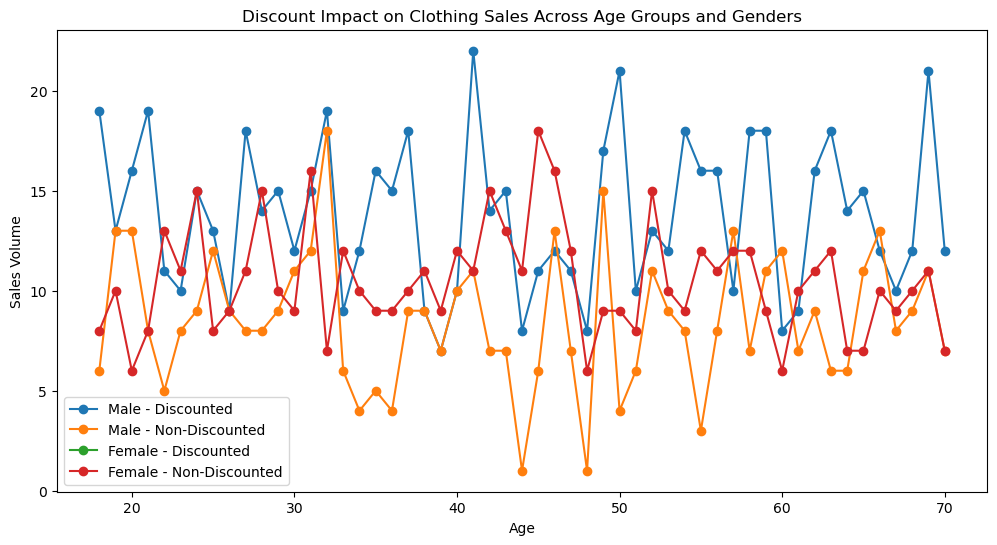

In [19]:
clothing_data = shopping_trends[shopping_trends['Category'] == 'Clothing']

grouped_data = clothing_data.groupby(['Age', 'Gender', 'Discount Applied']).size().reset_index(name='Sales Volume')

male_data = grouped_data[(grouped_data['Gender'] == 'Male')]
female_data = grouped_data[(grouped_data['Gender'] == 'Female')]

plt.figure(figsize=(12, 6))

plt.plot(male_data[male_data['Discount Applied'] == 'Yes']['Age'], male_data[male_data['Discount Applied'] == 'Yes']['Sales Volume'], label='Male - Discounted', marker='o')
plt.plot(male_data[male_data['Discount Applied'] == 'No']['Age'], male_data[male_data['Discount Applied'] == 'No']['Sales Volume'], label='Male - Non-Discounted', marker='o')

plt.plot(female_data[female_data['Discount Applied'] == 'Yes']['Age'], female_data[female_data['Discount Applied'] == 'Yes']['Sales Volume'], label='Female - Discounted', marker='o')
plt.plot(female_data[female_data['Discount Applied'] == 'No']['Age'], female_data[female_data['Discount Applied'] == 'No']['Sales Volume'], label='Female - Non-Discounted', marker='o')

plt.title('Discount Impact on Clothing Sales Across Age Groups and Genders')
plt.xlabel('Age')
plt.ylabel('Sales Volume')
plt.legend()


plt.show()



# Which age group responds most to discounts on 'Clothing' items?


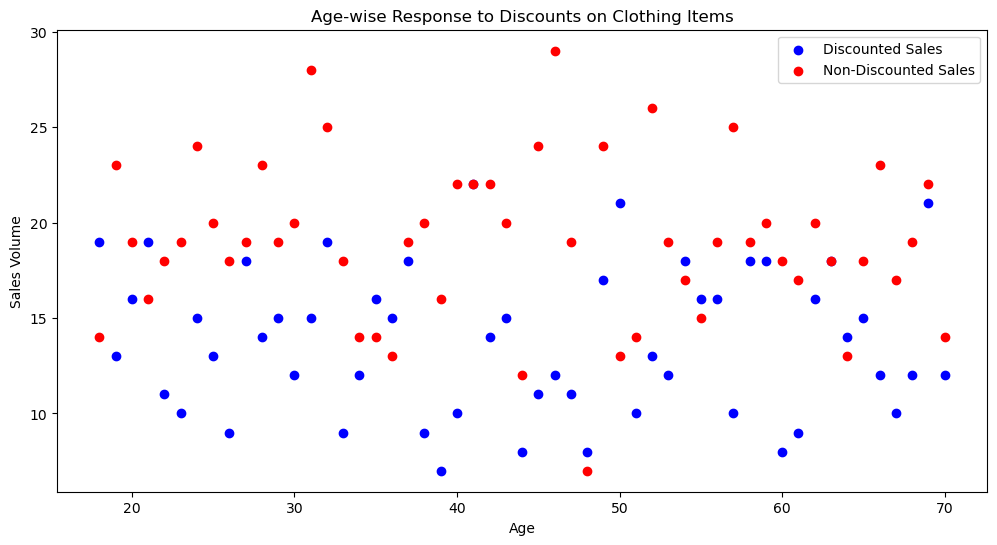

In [24]:
clothing_data = shopping_trends[shopping_trends['Category'] == 'Clothing']

age_discount_group = clothing_data.groupby(['Age', 'Discount Applied']).size().reset_index(name='Sales Volume')

discounted_sales = age_discount_group[age_discount_group['Discount Applied'] == 'Yes']
non_discounted_sales = age_discount_group[age_discount_group['Discount Applied'] == 'No']

plt.figure(figsize=(12, 6))

plt.scatter(discounted_sales['Age'], discounted_sales['Sales Volume'], label='Discounted Sales', color='blue')

plt.scatter(non_discounted_sales['Age'], non_discounted_sales['Sales Volume'], label='Non-Discounted Sales', color='red')


plt.title('Age-wise Response to Discounts on Clothing Items')
plt.xlabel('Age')
plt.ylabel('Sales Volume')
plt.legend()

plt.show()


# Data Visualization
# Matplotlib

In [25]:
import matplotlib.pyplot as plt

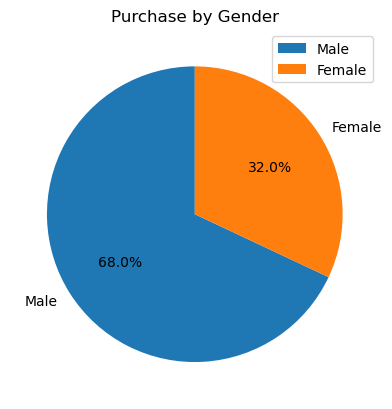

In [26]:
gender_type = shopping_trends['Gender'].value_counts()


plt.pie(gender_type, labels=gender_type.index, autopct='%1.1f%%', startangle=90)


plt.title('Purchase by Gender')
plt.legend()

plt.show()

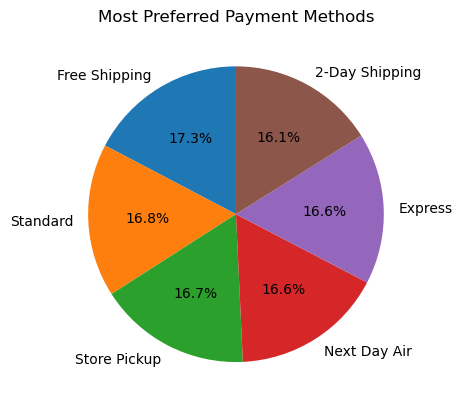

In [27]:
Shipping_Type = shopping_trends['Shipping Type'].value_counts()


plt.pie(Shipping_Type , labels=Shipping_Type .index, autopct='%1.1f%%', startangle=90)


plt.title('Most Preferred Payment Methods')


plt.show()

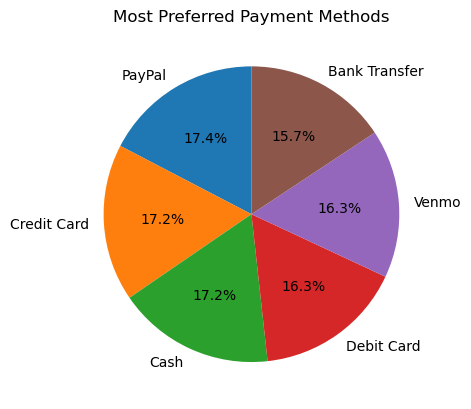

In [28]:
payment_counts = shopping_trends['Preferred Payment Method'].value_counts()


plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=90)


plt.title('Most Preferred Payment Methods')


plt.show()

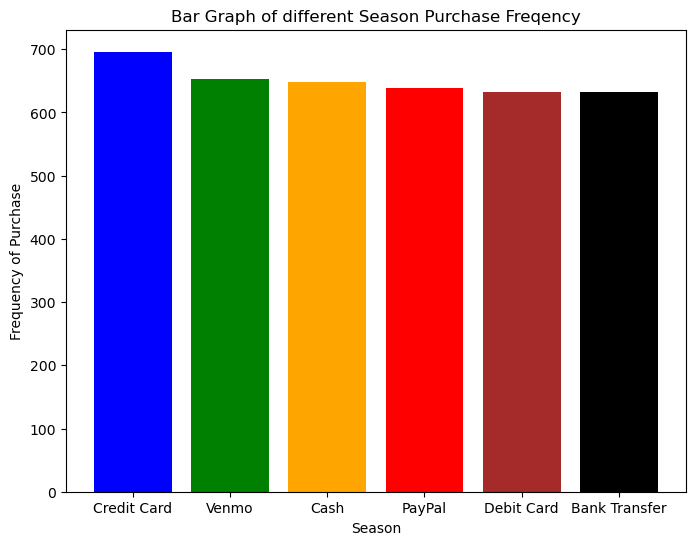

In [29]:
Customers_count = shopping_trends['Payment Method'].value_counts()

plt.figure(figsize=(8,6))
plt.bar(Customers_count.index, Customers_count.values, color=['blue', 'green', 'orange' , 'red' ,'brown','black','cyan'])


plt.xlabel('Season')
plt.ylabel('Frequency of Purchase')
plt.title('Bar Graph of different Season Purchase Freqency')


plt.show()

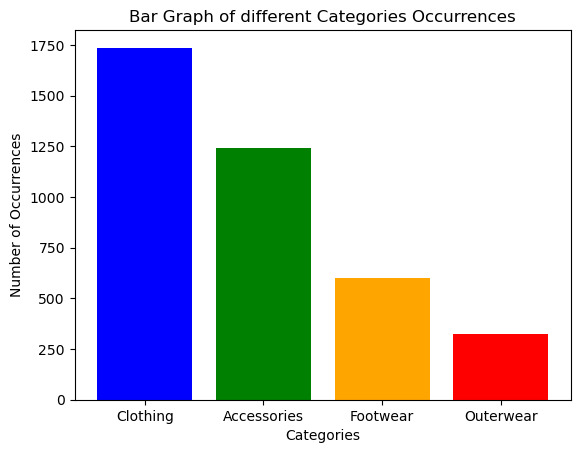

In [30]:
Customers_count = shopping_trends['Category'].value_counts()


plt.bar(Customers_count.index, Customers_count.values, color=['blue', 'green', 'orange' , 'red'])


plt.xlabel('Categories')
plt.ylabel('Number of Occurrences')
plt.title('Bar Graph of different Categories Occurrences')


plt.show()

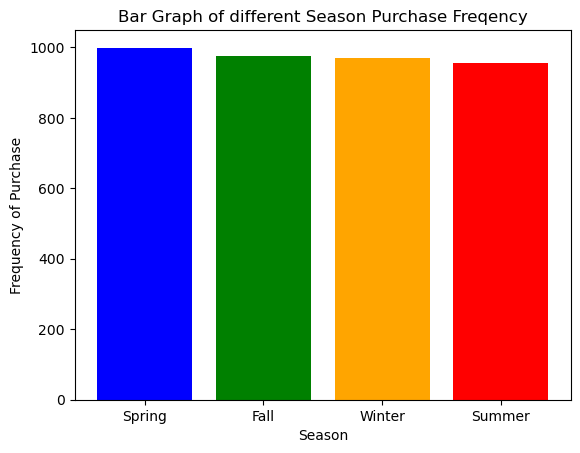

In [31]:
Customers_count = shopping_trends['Season'].value_counts()


plt.bar(Customers_count.index, Customers_count.values, color=['blue', 'green', 'orange' , 'red'])


plt.xlabel('Season')
plt.ylabel('Frequency of Purchase')
plt.title('Bar Graph of different Season Purchase Freqency')


plt.show()

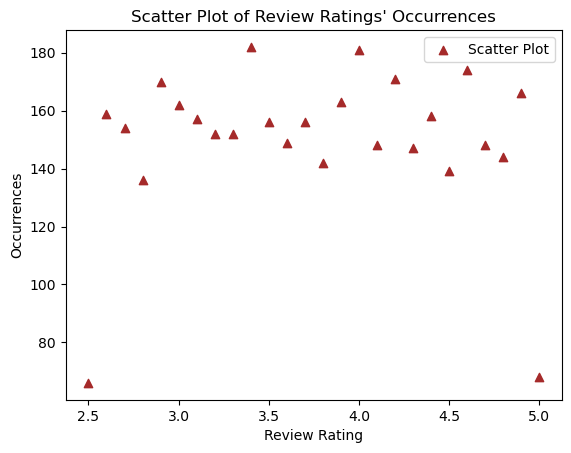

In [32]:
Review_count = shopping_trends['Review Rating'].value_counts()
plt.scatter(Review_count.index, Review_count, marker='^',color='brown', label='Scatter Plot')

plt.title("Scatter Plot of Review Ratings' Occurrences")
plt.xlabel('Review Rating')
plt.ylabel('Occurrences')
plt.legend()
plt.show()

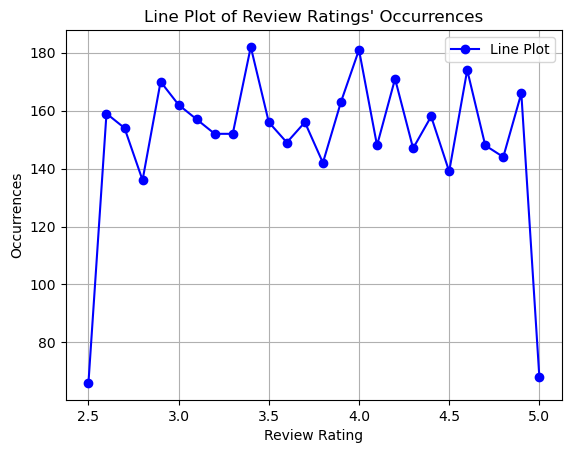

In [33]:
Review_count = shopping_trends['Review Rating'].value_counts()


Review_count = Review_count.sort_index()
plt.plot(Review_count.index, Review_count, marker='o', linestyle='-', color='blue', label='Line Plot')

plt.title("Line Plot of Review Ratings' Occurrences")
plt.xlabel('Review Rating')
plt.ylabel('Occurrences')
plt.legend()

plt.grid(True)
plt.show()

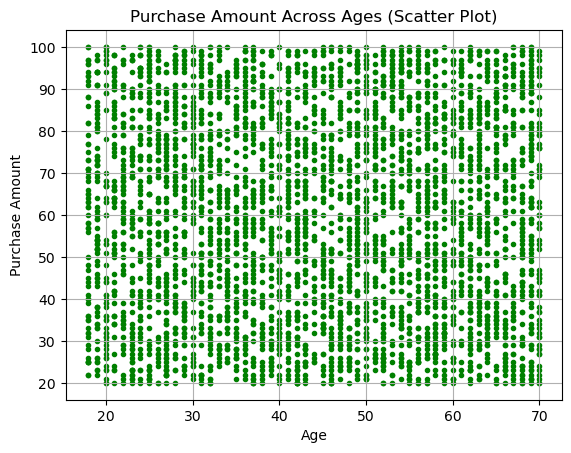

In [34]:
plt.scatter(shopping_trends['Age'], shopping_trends['Purchase Amount (USD)'], marker='.', color='g')


plt.title('Purchase Amount Across Ages (Scatter Plot)')
plt.xlabel('Age')
plt.ylabel('Purchase Amount')


plt.grid(True)
plt.show()

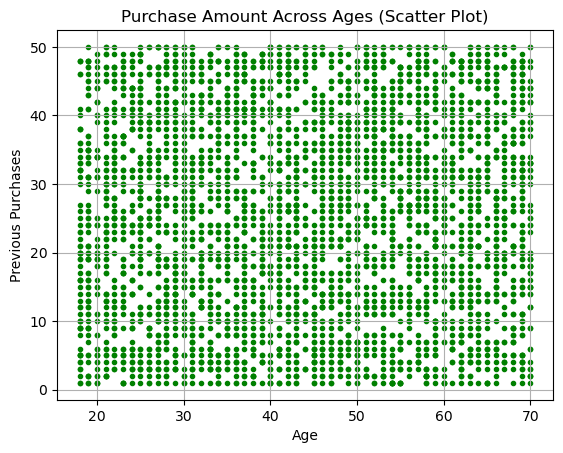

In [35]:
plt.scatter(shopping_trends['Age'], shopping_trends['Previous Purchases'], marker='.', color='g')


plt.title('Purchase Amount Across Ages (Scatter Plot)')
plt.xlabel('Age')
plt.ylabel('Previous Purchases')


plt.grid(True)
plt.show()

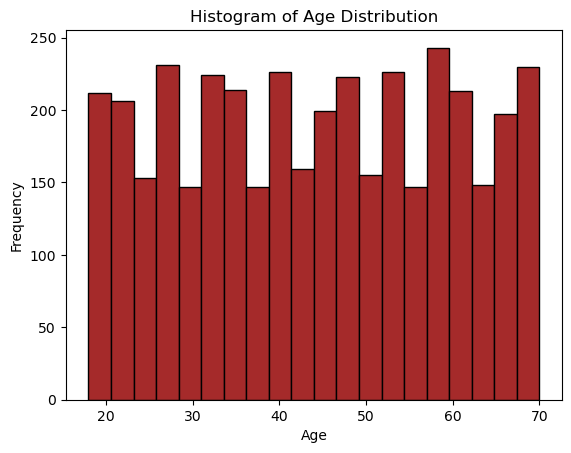

In [36]:
import numpy as np


Review_count = shopping_trends['Age']


plt.hist(Review_count, bins=20, color='brown', edgecolor='black')


plt.title("Histogram of Age Distribution")
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.show()

# SeaBorn

In [37]:
import seaborn as sns

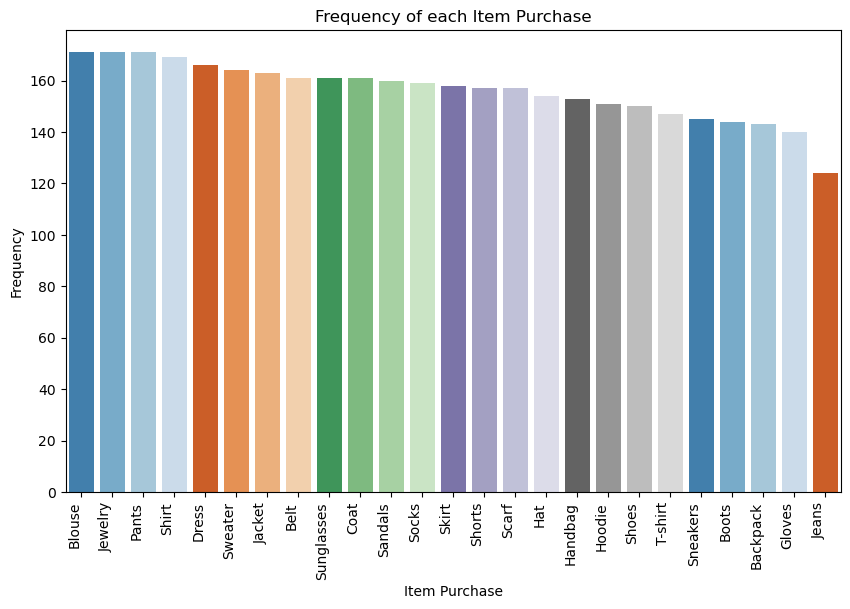

In [38]:
Customers_count = shopping_trends['Item Purchased'].value_counts()


plt.figure(figsize=(10, 6))  
sns.barplot(x=Customers_count.index, y=Customers_count.values, palette='tab20c')


plt.xlabel('Item Purchase')
plt.ylabel('Frequency')
plt.title('Frequency of each Item Purchase')


plt.xticks(rotation=90, ha='right')


plt.show()

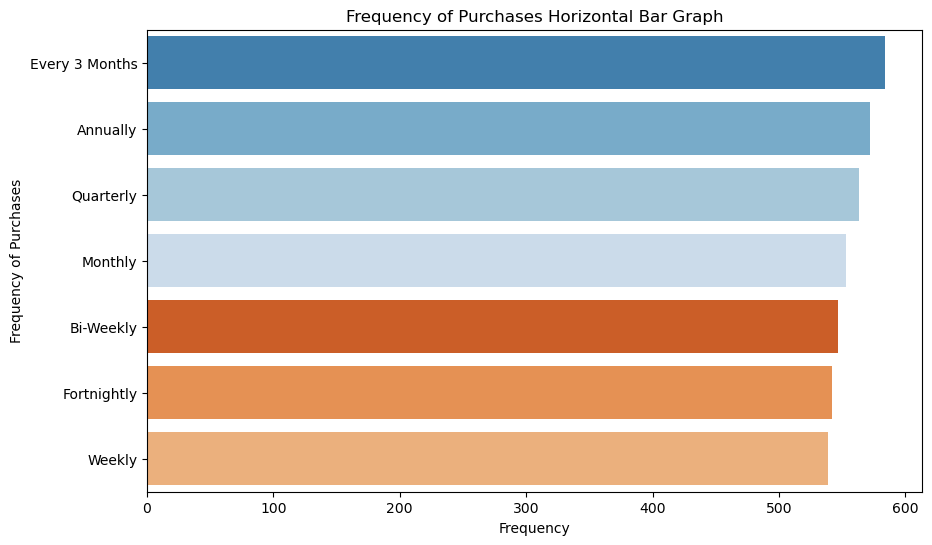

In [39]:
Customers_count = shopping_trends['Frequency of Purchases'].value_counts()


plt.figure(figsize=(10, 6))  

sns.barplot(x=Customers_count.values, y=Customers_count.index, palette='tab20c')


plt.xlabel('Frequency')  
plt.ylabel('Frequency of Purchases')  
plt.title('Frequency of Purchases Horizontal Bar Graph')


plt.show()

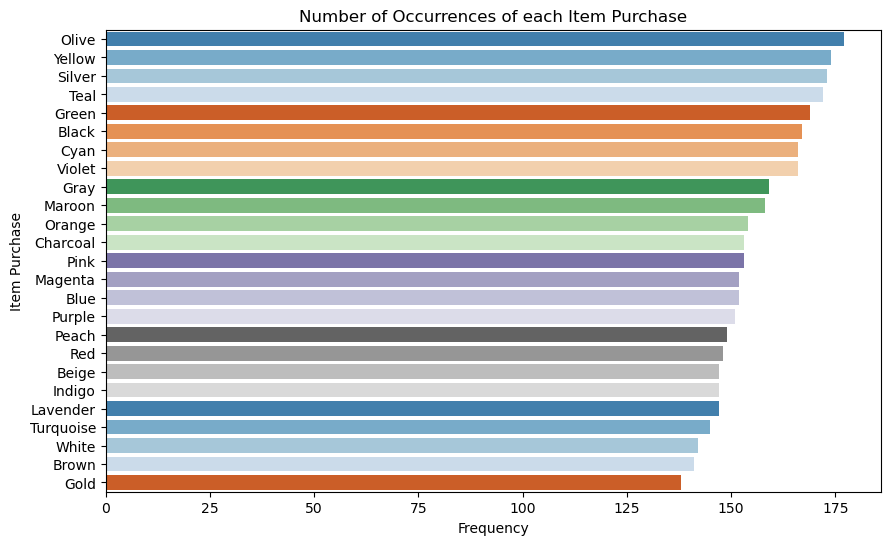

In [40]:
Customers_count = shopping_trends['Color'].value_counts()


plt.figure(figsize=(10, 6))  


sns.barplot(x=Customers_count.values, y=Customers_count.index, palette='tab20c')


plt.xlabel('Frequency')  
plt.ylabel('Item Purchase') 
plt.title('Number of Occurrences of each Item Purchase')


plt.show()

# IF , Else

In [41]:
Customer_A = shopping_trends [(shopping_trends.Category =='Clothing') & (shopping_trends.Age > 50) & (shopping_trends.Gender =='Male') & (shopping_trends.Size == 'L')]
Customer_A

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
27,28,56,Male,Shorts,Clothing,56,Kentucky,L,Cyan,Summer,5.0,Yes,Debit Card,Next Day Air,Yes,Yes,7,Bank Transfer,Every 3 Months
33,34,54,Male,Pants,Clothing,38,Colorado,L,Green,Summer,3.3,Yes,Venmo,Store Pickup,Yes,Yes,45,Cash,Quarterly
46,47,57,Male,Shirt,Clothing,43,California,L,White,Summer,2.9,Yes,Venmo,Store Pickup,Yes,Yes,45,Cash,Quarterly
102,103,51,Male,Socks,Clothing,67,Oklahoma,L,Violet,Winter,4.8,Yes,Credit Card,Next Day Air,Yes,Yes,35,Credit Card,Quarterly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2594,2595,59,Male,Skirt,Clothing,81,Montana,L,Indigo,Fall,3.6,No,Credit Card,Free Shipping,No,No,25,Cash,Every 3 Months
2596,2597,63,Male,Shirt,Clothing,78,Louisiana,L,Black,Spring,3.0,No,Venmo,Next Day Air,No,No,35,Credit Card,Monthly
2601,2602,61,Male,Dress,Clothing,33,Mississippi,L,Orange,Winter,2.9,No,PayPal,Store Pickup,No,No,43,Cash,Monthly
2619,2620,68,Male,Pants,Clothing,40,Connecticut,L,Indigo,Winter,3.9,No,Credit Card,Free Shipping,No,No,47,Credit Card,Weekly


In [42]:
Customer_B = shopping_trends[(shopping_trends.Category=='Outerwear') & (shopping_trends.Size == 'M') & (shopping_trends.Gender =='Female') & (shopping_trends.Season == 'Winter')]
Customer_B

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
2796,2797,55,Female,Jacket,Outerwear,73,Oklahoma,M,Red,Winter,3.8,No,Cash,Store Pickup,No,No,21,Cash,Annually
2856,2857,65,Female,Jacket,Outerwear,48,Iowa,M,Indigo,Winter,3.5,No,Debit Card,2-Day Shipping,No,No,31,Credit Card,Monthly
3019,3020,19,Female,Jacket,Outerwear,44,Utah,M,Yellow,Winter,3.9,No,Venmo,2-Day Shipping,No,No,15,PayPal,Annually
3109,3110,60,Female,Jacket,Outerwear,92,Illinois,M,Gray,Winter,4.3,No,Credit Card,Free Shipping,No,No,47,Bank Transfer,Fortnightly
3251,3252,25,Female,Coat,Outerwear,20,Nevada,M,Gold,Winter,3.7,No,Debit Card,Standard,No,No,39,Venmo,Quarterly
3310,3311,45,Female,Jacket,Outerwear,27,Iowa,M,Pink,Winter,3.6,No,Debit Card,Free Shipping,No,No,12,PayPal,Fortnightly
3591,3592,48,Female,Jacket,Outerwear,89,South Dakota,M,Gold,Winter,3.2,No,Cash,2-Day Shipping,No,No,38,Bank Transfer,Quarterly


In [43]:
Customer_C=shopping_trends[(shopping_trends.Age > 65 )& (shopping_trends.Size == 'L') & (shopping_trends.Gender =='Female') & (shopping_trends.Category=='Accessories')]
Customer_C

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
2778,2779,70,Female,Belt,Accessories,57,Pennsylvania,L,Yellow,Spring,3.2,No,Cash,Standard,No,No,24,Credit Card,Bi-Weekly
2839,2840,70,Female,Scarf,Accessories,80,South Dakota,L,Teal,Summer,2.8,No,Cash,Store Pickup,No,No,30,Bank Transfer,Monthly
2847,2848,68,Female,Jewelry,Accessories,21,Connecticut,L,Charcoal,Winter,2.8,No,Venmo,Free Shipping,No,No,3,PayPal,Every 3 Months
2980,2981,70,Female,Gloves,Accessories,93,New Jersey,L,Teal,Fall,4.4,No,Cash,2-Day Shipping,No,No,9,Bank Transfer,Monthly
3284,3285,70,Female,Scarf,Accessories,79,Kentucky,L,White,Spring,4.5,No,Debit Card,2-Day Shipping,No,No,20,Venmo,Annually
3404,3405,69,Female,Gloves,Accessories,34,South Carolina,L,Olive,Fall,3.9,No,Cash,2-Day Shipping,No,No,34,Credit Card,Annually
3458,3459,68,Female,Jewelry,Accessories,37,West Virginia,L,Violet,Spring,3.4,No,PayPal,Standard,No,No,24,Venmo,Quarterly
3551,3552,66,Female,Gloves,Accessories,31,Montana,L,Black,Spring,2.6,No,Credit Card,Store Pickup,No,No,20,Venmo,Weekly
3558,3559,68,Female,Backpack,Accessories,94,Alaska,L,Magenta,Summer,4.8,No,Credit Card,Standard,No,No,9,Venmo,Quarterly
3704,3705,68,Female,Sunglasses,Accessories,61,Missouri,L,Black,Winter,4.0,No,PayPal,Store Pickup,No,No,36,Credit Card,Quarterly


In [44]:
Customer_D=shopping_trends[(shopping_trends.Age == 18 ) & (shopping_trends.Size == 'S')]
Customer_D

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
1067,1068,18,Male,Dress,Clothing,43,Pennsylvania,S,Peach,Summer,2.7,No,Venmo,2-Day Shipping,Yes,Yes,22,PayPal,Quarterly
1079,1080,18,Male,Coat,Outerwear,33,Oklahoma,S,Blue,Summer,4.4,No,Bank Transfer,Free Shipping,Yes,Yes,48,Bank Transfer,Monthly
1574,1575,18,Male,Skirt,Clothing,25,Minnesota,S,Magenta,Spring,4.2,No,Bank Transfer,Free Shipping,Yes,Yes,32,PayPal,Bi-Weekly
1869,1870,18,Male,Blouse,Clothing,77,West Virginia,S,Beige,Spring,3.9,No,PayPal,2-Day Shipping,No,No,16,Debit Card,Every 3 Months
1922,1923,18,Male,Gloves,Accessories,63,Kentucky,S,Peach,Summer,4.6,No,PayPal,Standard,No,No,9,PayPal,Monthly
2282,2283,18,Male,Sneakers,Footwear,97,Idaho,S,Red,Fall,4.2,No,Debit Card,2-Day Shipping,No,No,8,Credit Card,Annually
2478,2479,18,Male,Socks,Clothing,93,Vermont,S,Maroon,Winter,4.8,No,Cash,2-Day Shipping,No,No,9,Bank Transfer,Every 3 Months
2498,2499,18,Male,Coat,Outerwear,39,Massachusetts,S,Green,Fall,2.6,No,Cash,Next Day Air,No,No,38,Cash,Fortnightly
2805,2806,18,Female,Sunglasses,Accessories,97,Nevada,S,Black,Fall,4.3,No,Cash,Standard,No,No,48,Cash,Quarterly
3307,3308,18,Female,Scarf,Accessories,36,Pennsylvania,S,Green,Winter,4.0,No,Credit Card,Store Pickup,No,No,1,Cash,Monthly


In [45]:
Customer_E = shopping_trends[(shopping_trends['Payment Method'] == 'Credit Card') | (shopping_trends['Payment Method'] == 'Debit Card')]
Customer_E

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
6,7,63,Male,Shirt,Clothing,85,Montana,M,Gray,Fall,3.2,Yes,Debit Card,Free Shipping,Yes,Yes,49,Cash,Quarterly
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Debit Card,Free Shipping,Yes,Yes,19,Credit Card,Weekly
10,11,53,Male,Shoes,Footwear,34,Arkansas,L,Purple,Fall,4.1,Yes,Credit Card,Store Pickup,Yes,Yes,26,Bank Transfer,Bi-Weekly
13,14,65,Male,Dress,Clothing,51,New Hampshire,M,Violet,Spring,4.7,Yes,Debit Card,Express,Yes,Yes,31,PayPal,Weekly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3882,3883,35,Female,Pants,Clothing,95,North Dakota,L,Blue,Fall,2.6,No,Credit Card,Free Shipping,No,No,24,Cash,Fortnightly
3884,3885,47,Female,Sandals,Footwear,29,Maryland,M,Brown,Fall,4.9,No,Debit Card,Express,No,No,3,PayPal,Weekly
3889,3890,57,Female,Dress,Clothing,65,Alaska,S,Yellow,Spring,3.5,No,Debit Card,Express,No,No,49,Bank Transfer,Annually
3890,3891,35,Female,Shirt,Clothing,81,Nebraska,XL,Green,Winter,2.6,No,Credit Card,Standard,No,No,33,Debit Card,Annually


In [46]:
Customer_F = shopping_trends[(shopping_trends['Preferred Payment Method'] == 'Credit Card') & (shopping_trends['Payment Method'] == 'Debit Card') ]
Customer_F

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
7,8,27,Male,Shorts,Clothing,34,Louisiana,L,Charcoal,Winter,3.2,Yes,Debit Card,Free Shipping,Yes,Yes,19,Credit Card,Weekly
53,54,29,Male,Skirt,Clothing,24,Mississippi,S,Peach,Winter,3.9,Yes,Debit Card,Next Day Air,Yes,Yes,35,Credit Card,Weekly
75,76,64,Male,Scarf,Accessories,85,Utah,M,Blue,Summer,2.7,Yes,Debit Card,Free Shipping,Yes,Yes,21,Credit Card,Annually
164,165,59,Male,Handbag,Accessories,65,Delaware,S,Purple,Spring,2.6,Yes,Debit Card,Free Shipping,Yes,Yes,5,Credit Card,Fortnightly
171,172,29,Male,Shorts,Clothing,35,Virginia,M,Blue,Summer,3.6,Yes,Debit Card,Store Pickup,Yes,Yes,4,Credit Card,Weekly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3742,3743,56,Female,Shirt,Clothing,80,Maryland,M,Gray,Fall,4.4,No,Debit Card,Standard,No,No,50,Credit Card,Bi-Weekly
3776,3777,19,Female,Sneakers,Footwear,25,Alaska,L,Olive,Spring,4.1,No,Debit Card,Standard,No,No,10,Credit Card,Fortnightly
3805,3806,48,Female,Scarf,Accessories,57,New Jersey,M,Green,Fall,3.1,No,Debit Card,Standard,No,No,31,Credit Card,Quarterly
3816,3817,29,Female,Coat,Outerwear,86,Maryland,S,Silver,Summer,4.3,No,Debit Card,Store Pickup,No,No,45,Credit Card,Fortnightly
